In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1990888583" 
# tab_gid = '908803302'
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:15, :]
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.00
1,pythia-70M,8-bit,41.39
2,pythia-70M,4-bit,39.21
3,pythia-160M,Original,42.49
4,pythia-160M,8-bit,42.31
5,pythia-160M,4-bit,40.60
6,pythia-410M,Original,43.51
7,pythia-410M,8-bit,43.61
8,pythia-410M,4-bit,42.41
9,pythia-1B,Original,44.18


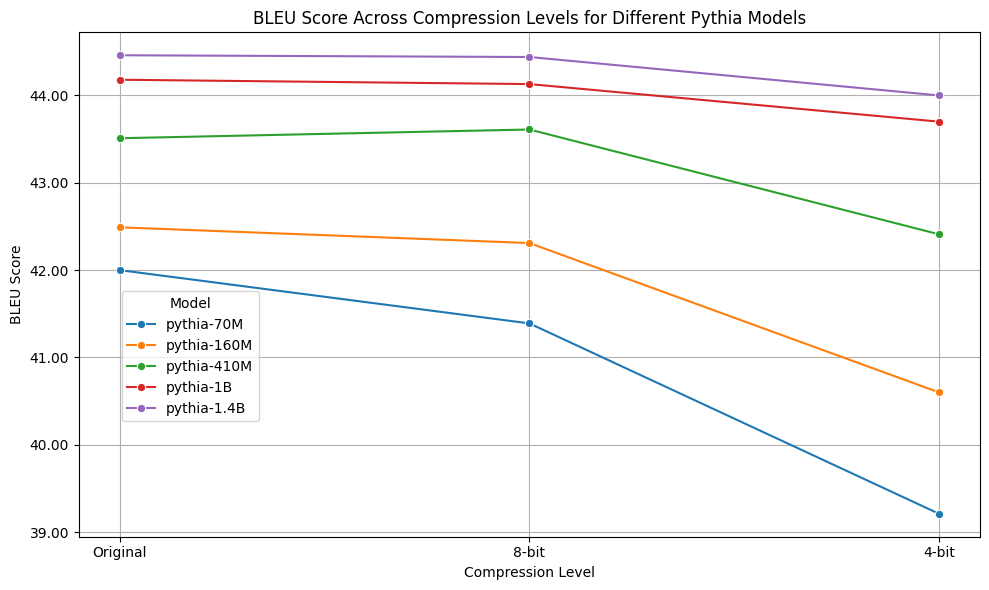

In [25]:
compression_order = ["Original", "8-bit", "4-bit"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o")

plt.title("BLEU Score Across Compression Levels for Different Pythia Models")
plt.ylabel("BLEU Score")
plt.xlabel("Compression Level")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
#show middle values of y axis intervals
# plt.gca().set_yticks(np.arange(39, 45, 0.5))



plt.grid(True)
plt.legend(title="Model", bbox_to_anchor=(.04, .5), loc="upper left")
plt.tight_layout()
plt.savefig("./output/RQ-1.png", dpi=300, bbox_inches="tight")
plt.show()